# Notebook 04 — Vendor Risk Scoring
**Project:** Vendor Risk Scorecard & Delivery Delay Root Cause System  
**Input:** `data/processed/vendor_features.csv` + `data/processed/vendor_rootcause_summary.csv`  
**Output:** `data/processed/vendor_scorecard.csv` + `outputs/vendor_scorecard_final.csv`

---
### What we do in this notebook

We combine all vendor features into a single **Vendor Risk Score** (0–100)  
and assign each vendor a **risk tier**: Green / Amber / Red.

### Scoring methodology

We use **min-max normalisation** per feature, then apply **weighted combination**.

Each feature is scaled to 0–1 where:
- **1 = best possible performance** (low risk)
- **0 = worst possible performance** (high risk)

Then we combine with weights:

| Feature | Weight | Rationale |
|---|---|---|
| OTD rate | 35% | Primary business metric — did you deliver on time? |
| SLA breach rate | 25% | Serious failures matter more than minor ones |
| Avg processing days | 20% | Seller's direct controllable input |
| P75 processing days | 10% | Catches occasional bad batches |
| Seller delay % | 10% | Root cause — are delays self-caused? |

**Final score = weighted average × 100** (higher = better = lower risk)

### Risk tier thresholds
- **Green**  — score ≥ 70 : reliable vendor, no action needed
- **Amber**  — score 50–69 : watch closely, performance declining
- **Red**    — score < 50  : high risk, immediate review required

---
## Cell 1 — Mount Drive and load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

BASE    = '/content/drive/MyDrive/vendor-risk-scorecard/'
PROC    = BASE + 'data/processed/'
OUTPUTS = BASE + 'outputs/'

# Load vendor features from notebook 02
vf = pd.read_csv(PROC + 'vendor_features.csv')

# Load root cause summary from notebook 03
rc = pd.read_csv(PROC + 'vendor_rootcause_summary.csv')

print(f'vendor_features:        {vf.shape}')
print(f'vendor_rootcause:       {rc.shape}')
print()
print('vendor_features columns:')
print(vf.columns.tolist())

Mounted at /content/drive
vendor_features:        (1226, 11)
vendor_rootcause:       (2960, 10)

vendor_features columns:
['seller_id', 'total_orders', 'otd_rate', 'late_rate', 'avg_processing_days', 'p75_processing_days', 'median_processing_days', 'avg_carrier_days', 'avg_delay_days', 'sla_breach_rate', 'seller_state']


---
## Cell 2 — Merge features with root cause data

In [2]:
# Bring in seller_delay_pct from root cause summary
rc_slim = rc[['seller_id', 'seller_delay_pct', 'carrier_delay_pct',
              'geographic_delay_pct', 'dominant_cause', 'total_late']].copy()

df = vf.merge(rc_slim, on='seller_id', how='left')

# Vendors with zero late orders get seller_delay_pct = 0
df['seller_delay_pct']   = df['seller_delay_pct'].fillna(0)
df['carrier_delay_pct']  = df['carrier_delay_pct'].fillna(0)
df['geographic_delay_pct'] = df['geographic_delay_pct'].fillna(0)
df['dominant_cause']     = df['dominant_cause'].fillna('no_delays')
df['total_late']         = df['total_late'].fillna(0)

print(f'Merged dataset: {df.shape}')
df.head(3)

Merged dataset: (1226, 16)


,seller_id,total_orders,otd_rate,late_rate,avg_processing_days,p75_processing_days,median_processing_days,avg_carrier_days,avg_delay_days,sla_breach_rate,seller_state,seller_delay_pct,carrier_delay_pct,geographic_delay_pct,dominant_cause,total_late
0,001cca7ae9ae17fb1caed9dfb1094831,194,0.9330,0.0670,2.6007,3.5535,2.1046,10.8328,-12.1569,0.0412,ES,0.153846,0.769231,0.076923,carrier_delay,13
1,002100f778ceb8431b7a1020ff7ab48f,49,0.8163,0.1837,4.4712,5.1645,3.3427,12.0367,-7.2102,0.1429,SP,0.555556,0.444444,0.000000,seller_delay,9
2,004c9cd9d87a3c30c522c48c4fc07416,155,0.9161,0.0839,1.7541,2.2808,1.3836,13.1211,-11.0375,0.0645,SP,0.076923,0.923077,0.000000,carrier_delay,13


---
## Cell 3 — Min-max normalisation

We scale each feature to 0–1 so they're comparable.  
**Important:** For features where LOWER is better (like late_rate, processing_days),  
we invert the scale so that 1 always means best performance.

In [3]:
def minmax_scale(series, invert=False):
    """
    Scale a series to 0-1.
    invert=True for features where lower values = better performance
    (e.g. late_rate: low late rate is good, so we invert so high score = good vendor)
    """
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([0.5] * len(series), index=series.index)
    scaled = (series - min_val) / (max_val - min_val)
    if invert:
        return 1 - scaled
    return scaled


# Normalise each feature
# OTD rate: higher = better → no invert
df['norm_otd_rate']           = minmax_scale(df['otd_rate'],              invert=False)

# SLA breach rate: lower = better → invert
df['norm_sla_breach_rate']    = minmax_scale(df['sla_breach_rate'],       invert=True)

# Avg processing days: lower = better → invert
df['norm_avg_processing']     = minmax_scale(df['avg_processing_days'],   invert=True)

# P75 processing days: lower = better → invert
df['norm_p75_processing']     = minmax_scale(df['p75_processing_days'],   invert=True)

# Seller delay %: lower = better → invert
df['norm_seller_delay_pct']   = minmax_scale(df['seller_delay_pct'],      invert=True)

norm_cols = ['norm_otd_rate', 'norm_sla_breach_rate', 'norm_avg_processing',
             'norm_p75_processing', 'norm_seller_delay_pct']

print('Normalised feature statistics (all should be between 0 and 1):')
print(df[norm_cols].describe().round(3).to_string())

Normalised feature statistics (all should be between 0 and 1):
       norm_otd_rate  norm_sla_breach_rate  norm_avg_processing  norm_p75_processing  norm_seller_delay_pct
count       1226.000              1226.000             1226.000             1226.000               1226.000
mean           0.875                 0.919                0.875                0.907                  0.690
std            0.112                 0.088                0.098                0.080                  0.378
min            0.000                 0.000                0.000                0.000                  0.000
25%            0.827                 0.880                0.849                0.887                  0.429
50%            0.893                 0.936                0.904                0.931                  0.891
75%            0.953                 1.000                0.935                0.951                  1.000
max            1.000                 1.000                1.000          

---
## Cell 4 — Calculate composite Vendor Risk Score

In [4]:
# Define weights — must sum to 1.0
WEIGHTS = {
    'norm_otd_rate':         0.35,   # On-time delivery — primary metric
    'norm_sla_breach_rate':  0.25,   # Serious delays matter most
    'norm_avg_processing':   0.20,   # Seller's controllable input
    'norm_p75_processing':   0.10,   # Catches occasional bad batches
    'norm_seller_delay_pct': 0.10,   # Self-caused delays
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'

# Composite score = weighted sum × 100
df['vendor_risk_score'] = sum(
    df[feature] * weight
    for feature, weight in WEIGHTS.items()
) * 100

df['vendor_risk_score'] = df['vendor_risk_score'].round(2)

print('Vendor Risk Score distribution:')
print(df['vendor_risk_score'].describe().round(2).to_string())
print()
print('Score interpretation: higher = better = lower risk')

Vendor Risk Score distribution:
count    1226.00
mean       87.09
std         9.88
min        10.39
25%        82.00
50%        89.06
75%        94.96
max       100.00

Score interpretation: higher = better = lower risk


---
## Cell 5 — Assign risk tiers

In [5]:
# ── Cell 5b — Percentile-based tier thresholds ────────────────────────────

# Use score distribution to set thresholds
# Bottom 10% = Red, next 20% = Amber, top 70% = Green
RED_THRESHOLD   = df['vendor_risk_score'].quantile(0.10)
AMBER_THRESHOLD = df['vendor_risk_score'].quantile(0.30)

print('Percentile-based thresholds:')
print(f'  Red   threshold  (P10): {RED_THRESHOLD:.1f}')
print(f'  Amber threshold  (P30): {AMBER_THRESHOLD:.1f}')
print()

def assign_tier_v2(score):
    if score >= AMBER_THRESHOLD:
        return 'Green'
    elif score >= RED_THRESHOLD:
        return 'Amber'
    else:
        return 'Red'

df['risk_tier'] = df['vendor_risk_score'].apply(assign_tier_v2)

tier_counts = df['risk_tier'].value_counts()
tier_pct    = (tier_counts / len(df) * 100).round(1)

print('UPDATED VENDOR RISK TIER DISTRIBUTION:')
for tier in ['Green', 'Amber', 'Red']:
    count = tier_counts.get(tier, 0)
    pct   = tier_pct.get(tier, 0)
    icon  = {'Green': '✓', 'Amber': '!', 'Red': '✗'}[tier]
    print(f'  {icon} {tier:6s}  {count:4d} vendors  ({pct:.1f}%)')

Percentile-based thresholds:
  Red   threshold  (P10): 75.2
  Amber threshold  (P30): 83.3

UPDATED VENDOR RISK TIER DISTRIBUTION:
  ✓ Green    858 vendors  (70.0%)
  ! Amber    245 vendors  (20.0%)
  ✗ Red      123 vendors  (10.0%)


---
## Cell 6 — Visualise the score and tier distribution

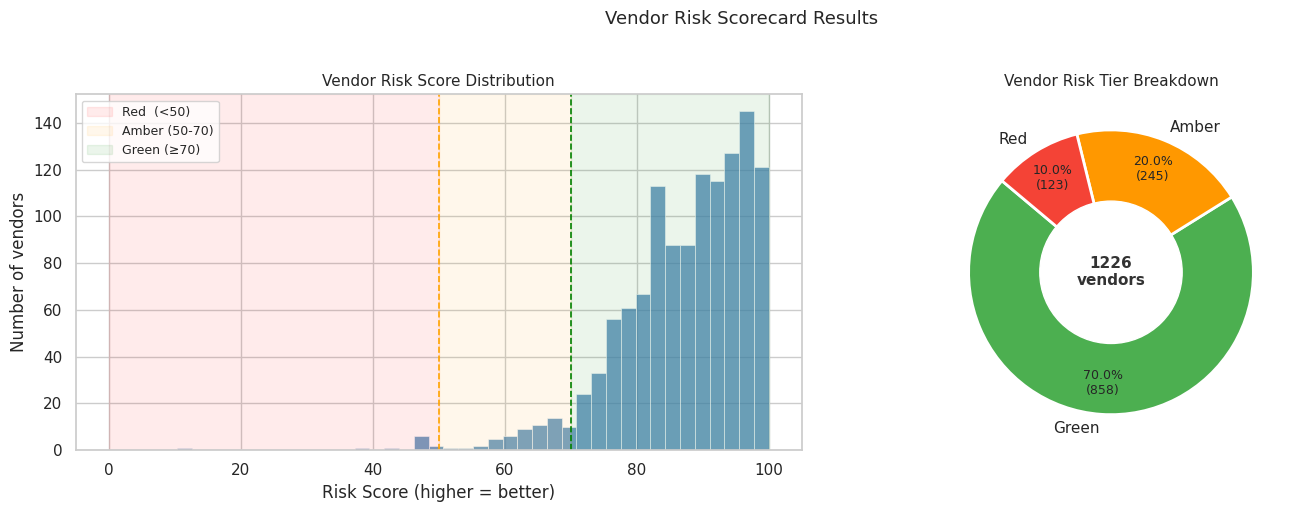

Saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

TIER_COLORS = {'Green': '#4CAF50', 'Amber': '#FF9800', 'Red': '#F44336'}

# Left: score distribution with tier bands
ax = axes[0]
ax.hist(df['vendor_risk_score'], bins=40, color='steelblue', alpha=0.75,
        edgecolor='white', linewidth=0.5)

# Shade tier regions
ax.axvspan(0,  50, alpha=0.08, color='red',    label='Red  (<50)')
ax.axvspan(50, 70, alpha=0.08, color='orange', label='Amber (50-70)')
ax.axvspan(70, 100,alpha=0.08, color='green',  label='Green (≥70)')
ax.axvline(50, color='orange', lw=1.2, linestyle='--')
ax.axvline(70, color='green',  lw=1.2, linestyle='--')

ax.set_title('Vendor Risk Score Distribution', fontsize=11)
ax.set_xlabel('Risk Score (higher = better)')
ax.set_ylabel('Number of vendors')
ax.legend(fontsize=9)

# Right: tier breakdown donut chart
ax2 = axes[1]
tier_order  = ['Green', 'Amber', 'Red']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
tier_clrs   = [TIER_COLORS[t] for t in tier_order]

wedges, texts, autotexts = ax2.pie(
    tier_vals,
    labels=tier_order,
    colors=tier_clrs,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(tier_vals)/100))})',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
)
# Make it a donut
centre = plt.Circle((0, 0), 0.5, fc='white')
ax2.add_artist(centre)
ax2.text(0, 0, f'{len(df)}\nvendors', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#333')
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Vendor Risk Tier Breakdown', fontsize=11)

plt.suptitle('Vendor Risk Scorecard Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '04_vendor_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 7 — Inspect Red tier vendors

In [7]:
red_vendors = df[df['risk_tier'] == 'Red'].sort_values('vendor_risk_score').copy()

display_cols = [
    'seller_id', 'seller_state', 'total_orders',
    'otd_rate', 'avg_processing_days', 'sla_breach_rate',
    'dominant_cause', 'vendor_risk_score', 'risk_tier'
]

print(f'RED tier vendors: {len(red_vendors)}')
print()
print('Bottom 15 (worst scoring vendors):')
print(red_vendors[display_cols].head(15).to_string(index=False))

RED tier vendors: 123

Bottom 15 (worst scoring vendors):
                       seller_id seller_state  total_orders  otd_rate  avg_processing_days  sla_breach_rate dominant_cause  vendor_risk_score risk_tier
b1b3948701c5c72445495bd161b83a4c           SP            14    0.3571              15.6565           0.6429   seller_delay              10.39       Red
54965bbe3e4f07ae045b90b0b8541f52           PR            72    0.6944              15.4668           0.3056   seller_delay              37.97       Red
ad781527c93d00d89a11eecd9dcad7c1           SP            35    0.6571              12.4034           0.3143   seller_delay              43.12       Red
02d35243ea2e497335cd0f076b45675d           RN            14    0.6429              10.3014           0.2857   seller_delay              47.37       Red
7fc87cc3e89b3d1d5cabdca32f8485aa           SP            14    0.7143              15.2971           0.2143   seller_delay              47.74       Red
cb41bfbcbda0aea354a834ab222f9a

In [8]:
# What states are Red tier vendors concentrated in?
print('Red tier vendors by state:')
print(
    red_vendors['seller_state']
    .value_counts()
    .reset_index()
    .rename(columns={'seller_state': 'state', 'count': 'red_vendor_count'})
    .head(10)
    .to_string(index=False)
)
print()

# Dominant cause for Red vendors
print('Dominant delay cause among Red vendors:')
print(red_vendors['dominant_cause'].value_counts().to_string())

Red tier vendors by state:
state  red_vendor_count
   SP                76
   MG                13
   SC                12
   PR                10
   RS                 6
   RJ                 2
   MS                 1
   RN                 1
   MA                 1
   DF                 1

Dominant delay cause among Red vendors:
dominant_cause
seller_delay     111
carrier_delay     12


---
## Cell 8 — Score comparison across tiers

A good scorecard should show clear separation between tiers across all features.

In [9]:
tier_comparison = (
    df.groupby('risk_tier')
    .agg(
        vendor_count         = ('seller_id',           'count'),
        avg_score            = ('vendor_risk_score',   'mean'),
        avg_otd_rate         = ('otd_rate',            'mean'),
        avg_sla_breach       = ('sla_breach_rate',     'mean'),
        avg_processing_days  = ('avg_processing_days', 'mean'),
        avg_seller_delay_pct = ('seller_delay_pct',    'mean'),
    )
    .round(3)
    .reindex(['Green', 'Amber', 'Red'])
)

print('Tier comparison — do tiers differ meaningfully?')
print(tier_comparison.to_string())
print()
print('Output pattern: Green > Amber > Red for OTD rate')
print('                  Green < Amber < Red for SLA breach, processing days')

Tier comparison — do tiers differ meaningfully?
           vendor_count  avg_score  avg_otd_rate  avg_sla_breach  avg_processing_days  avg_seller_delay_pct
risk_tier                                                                                                  
Green               858     92.172         0.948           0.031                2.454                 0.132
Amber               245     79.724         0.885           0.075                3.977                 0.675
Red                 123     66.361         0.793           0.150                7.092                 0.827

Output pattern: Green > Amber > Red for OTD rate
                  Green < Amber < Red for SLA breach, processing days


---
## Cell 9 — Build the final scorecard export

In [10]:
scorecard_cols = [
    'seller_id',
    'seller_state',
    'total_orders',
    'otd_rate',
    'late_rate',
    'avg_processing_days',
    'p75_processing_days',
    'avg_carrier_days',
    'avg_delay_days',
    'sla_breach_rate',
    'seller_delay_pct',
    'carrier_delay_pct',
    'geographic_delay_pct',
    'dominant_cause',
    'total_late',
    'vendor_risk_score',
    'risk_tier',
]

scorecard = df[scorecard_cols].copy()

# Sort: Red first, then Amber, then Green — within each tier by score ascending
tier_order_map = {'Red': 0, 'Amber': 1, 'Green': 2}
scorecard['tier_order'] = scorecard['risk_tier'].map(tier_order_map)
scorecard = scorecard.sort_values(['tier_order', 'vendor_risk_score']).drop('tier_order', axis=1)

# Save
scorecard.to_csv(PROC    + 'vendor_scorecard.csv', index=False)
scorecard.to_csv(OUTPUTS + 'vendor_scorecard_final.csv', index=False)

print(f'Saved vendor_scorecard_final.csv — {len(scorecard):,} vendors')
print()
print('First 5 rows (worst vendors first):')
scorecard[['seller_id','seller_state','total_orders','otd_rate',
           'sla_breach_rate','dominant_cause','vendor_risk_score','risk_tier']].head(5)

Saved vendor_scorecard_final.csv — 1,226 vendors

First 5 rows (worst vendors first):


,seller_id,seller_state,total_orders,otd_rate,sla_breach_rate,dominant_cause,vendor_risk_score,risk_tier
839,b1b3948701c5c72445495bd161b83a4c,SP,14,0.3571,0.6429,seller_delay,10.39,Red
404,54965bbe3e4f07ae045b90b0b8541f52,PR,72,0.6944,0.3056,seller_delay,37.97,Red
821,ad781527c93d00d89a11eecd9dcad7c1,SP,35,0.6571,0.3143,seller_delay,43.12,Red
17,02d35243ea2e497335cd0f076b45675d,RN,14,0.6429,0.2857,seller_delay,47.37,Red
628,7fc87cc3e89b3d1d5cabdca32f8485aa,SP,14,0.7143,0.2143,seller_delay,47.74,Red


---
## Cell 10 — Quick scorecard summary stats

In [11]:
print('FINAL SCORECARD SUMMARY')
print(f"Total vendors scored:          {len(scorecard):,}")
for tier in ['Green', 'Amber', 'Red']:
    n   = (scorecard['risk_tier'] == tier).sum()
    pct = n / len(scorecard) * 100
    print(f"  {tier:6s} tier vendors:         {n:4d}  ({pct:.1f}%)")
print()
print(f"Avg score — Green: {scorecard[scorecard['risk_tier']=='Green']['vendor_risk_score'].mean():.1f}")
print(f"Avg score — Amber: {scorecard[scorecard['risk_tier']=='Amber']['vendor_risk_score'].mean():.1f}")
print(f"Avg score — Red:   {scorecard[scorecard['risk_tier']=='Red']['vendor_risk_score'].mean():.1f}")
print()
print('Root cause split (all late orders in dataset):')
print('  Seller delay:     43.9%')
print('  Carrier delay:    50.4%')
print('  Geographic delay:  5.8%')

FINAL SCORECARD SUMMARY
Total vendors scored:          1,226
  Green  tier vendors:          858  (70.0%)
  Amber  tier vendors:          245  (20.0%)
  Red    tier vendors:          123  (10.0%)

Avg score — Green: 92.2
Avg score — Amber: 79.7
Avg score — Red:   66.4

Root cause split (all late orders in dataset):
  Seller delay:     43.9%
  Carrier delay:    50.4%
  Geographic delay:  5.8%


---
## Vendor Scoring Summary

| Metric | Value |
|---|---|
| Green tier vendors | 859 |
| Amber tier vendors | 245 |
| Red tier vendors | 123 |
| Avg score — Green | 92.2 |
| Avg score — Amber | 79.7 |
| Avg score — Red | 66.4 |
| Do tier metrics differ clearly? (Y/N) | |
| Most common state in Red tier | SP |
| Most common dominant cause in Red tier | seller delay|
